## SECTION 0 — Setup & Imports

In [1]:
!pip3 install opencv-python-headless pandas matplotlib seaborn scikit-learn lightgbm timm pvlib psutil pytz


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, time, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import timm
from PIL import Image
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
warnings.filterwarnings("ignore")

# ── Paths: prefer the current folder if the dataset is here, else /workspace ──
import sys
ROOT = next((r for r in (os.path.abspath("."), "/workspace")
             if os.path.exists(f"{r}/data/combined_dataset.csv")), None)
if ROOT is None:
    raise FileNotFoundError(
        "data/combined_dataset.csv not found in current folder or /workspace — "
        "run combined_dataset.py, then run this notebook from the project folder.")

BASE_DIR = f"{ROOT}/data"
# NOAA AWS crops from himawari_aws.py (the old NICT tiles were the wrong region)
SAT_DIR  = f"{BASE_DIR}/satellite_aws"
NPY_DIR  = f"{BASE_DIR}/satellite_aws_npy"   # 224×224 cache of SAT_DIR
CSV_PATH = f"{BASE_DIR}/combined_dataset.csv"
RESULTS  = f"{ROOT}/results"

os.makedirs(f"{RESULTS}/plots", exist_ok=True)
os.makedirs(NPY_DIR, exist_ok=True)
print(f"ROOT: {ROOT}")

# ── Model definitions come from model.py (single source of truth) ─────────────
# Upload model.py alongside this notebook. predict.py/verify.py use the SAME
# classes, so a checkpoint trained here always loads for inference.
sys.path.insert(0, ROOT)
assert os.path.exists(f"{ROOT}/model.py"), \
    f"model.py not found in {ROOT} — upload it next to this notebook!"

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
    print("Using MPS with fallback")
else:
    device = torch.device("cpu")
    print("Using CPU")

# ── Platform-aware DataLoader settings ───────────────────────────────────────
is_linux   = platform.system() == "Linux"
NUM_WORKERS = 4 if is_linux else 0
PIN_MEMORY  = True if is_linux and torch.cuda.is_available() else False
print(f"Workers: {NUM_WORKERS} | pin_memory: {PIN_MEMORY}")

# ── AMP ───────────────────────────────────────────────────────────────────────
USE_AMP = torch.cuda.is_available()

# ── Image normalisation constants (ImageNet) ──────────────────────────────────
IMG_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMG_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

torch.manual_seed(42)
np.random.seed(42)
print("Setup complete ✓")


/Users/qasimnalawala/Desktop/Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /Users/qasimnalawala/Desktop/Project
Using MPS with fallback
Workers: 0 | pin_memory: False
Setup complete ✓


## SECTION 1 — Data Loading & EDA

Shape: (9880, 25)
Date range: 2024-01-01 08:00:00 → 2026-09-14 17:00:00
Total usable rows (image present): 9837


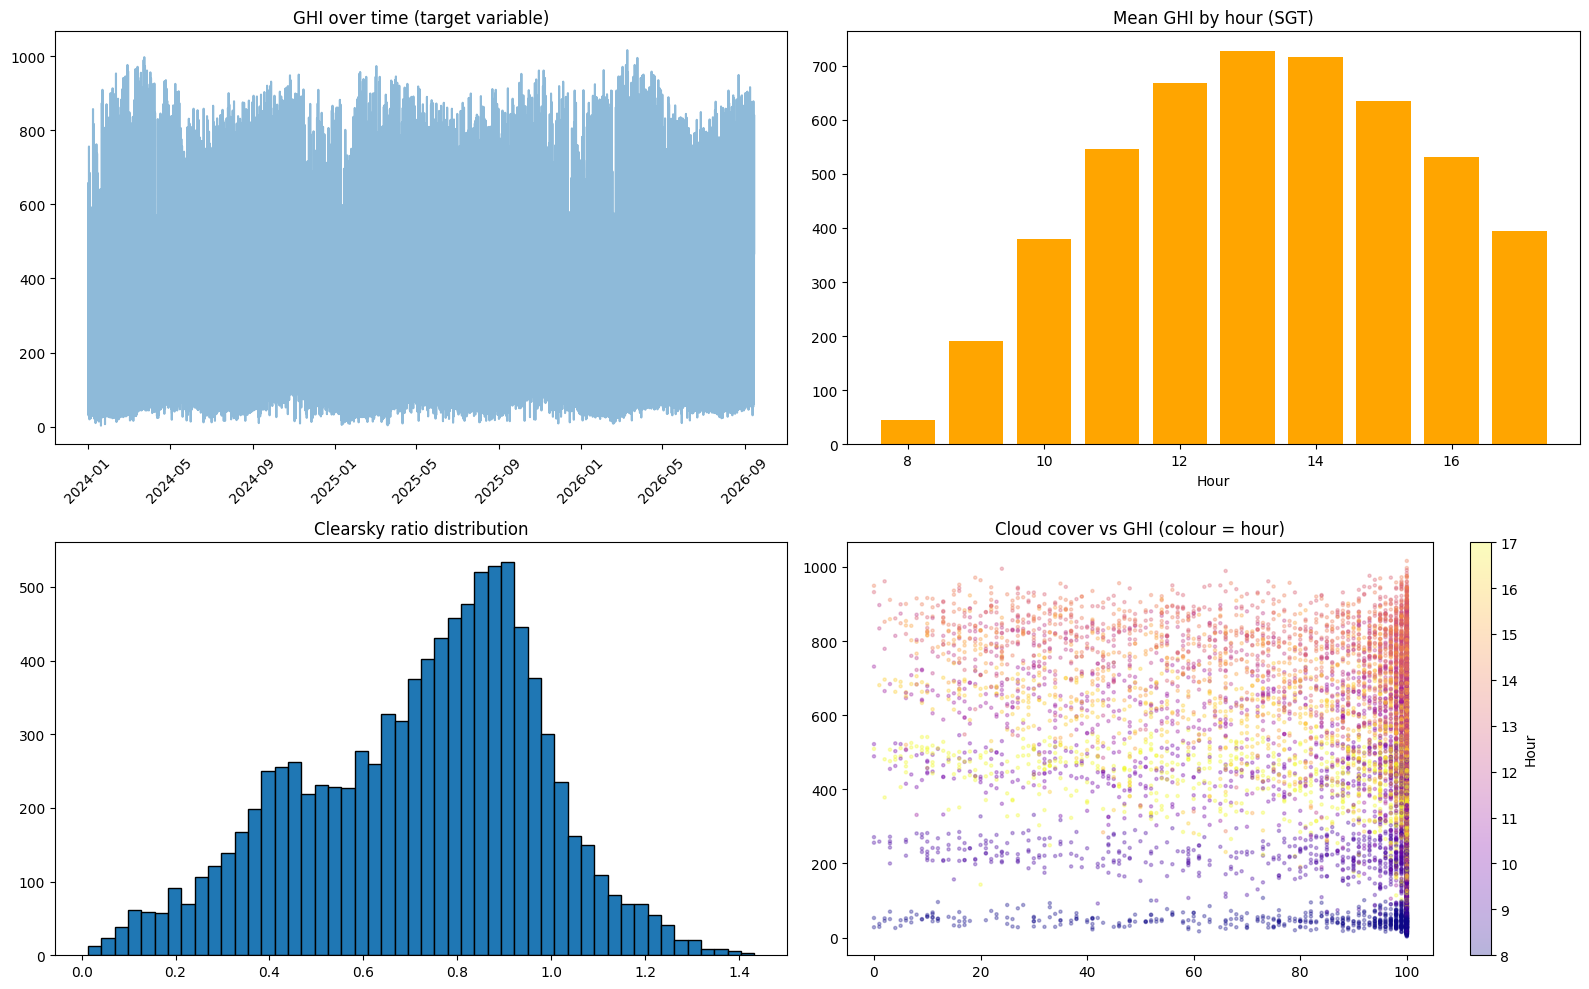


Correlation with GHI:
ghi                         1.000000
pv_power_predicted          0.999937
pv_actual                   0.999937
temperature_2m              0.864287
direct_normal_irradiance    0.822634
ghi_clearsky                0.822584
clearsky_ratio              0.769399
diffuse_radiation           0.539070
hour                        0.494471
wind_speed_10m              0.338413
Name: ghi, dtype: float64


In [3]:
df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# ── Remove leaky columns ──────────────────────────────────────────────────────
# pv_actual = 0.847 * ghi (r=0.9999) — drop as a feature, only keep for reference
# ghi will be used as TARGET (future values), not as an input feature for that step
LEAKY_COLS = ["pv_actual"]  # keep in df for reference but exclude from inputs

# ── Feature engineering ───────────────────────────────────────────────────────
df["clearsky_ratio"] = df["ghi"] / (df["ghi_clearsky"] + 1e-6)
df["hour"]           = df["timestamp"].dt.hour
df["month"]          = df["timestamp"].dt.month
df["sin_hour"]       = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"]       = np.cos(2 * np.pi * df["hour"] / 24)
df["sin_month"]      = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"]      = np.cos(2 * np.pi * df["month"] / 12)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Total usable rows (image present): {df['image_path'].notna().sum()}")

# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0,0].plot(df["timestamp"], df["ghi"], alpha=0.5)
axs[0,0].set_title("GHI over time (target variable)")
axs[0,0].tick_params(axis="x", rotation=45)

hourly = df.groupby("hour")["ghi"].mean()
axs[0,1].bar(hourly.index, hourly.values, color="orange")
axs[0,1].set_title("Mean GHI by hour (SGT)")
axs[0,1].set_xlabel("Hour")

axs[1,0].hist(df["clearsky_ratio"].clip(0, 1.5), bins=50, edgecolor="black")
axs[1,0].set_title("Clearsky ratio distribution")

sc = axs[1,1].scatter(df["cloud_cover"], df["ghi"], alpha=0.3, s=5, c=df["hour"], cmap="plasma")
plt.colorbar(sc, ax=axs[1,1], label="Hour")
axs[1,1].set_title("Cloud cover vs GHI (colour = hour)")

plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/eda.png", dpi=150)
plt.show()

print("\nCorrelation with GHI:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[num_cols].corr()["ghi"].sort_values(ascending=False).head(10))


## SECTION 2 — Baseline Model Honest

In [4]:
# ── Tabular features for baselines ───────────────────────────────────────────
# Only use features available at time t (no future GHI leaking in)
BASELINE_FEATURES = [
    "clearsky_ratio", "cloud_cover", "temperature_2m",
    "rain", "wind_speed_10m", "relative_humidity_2m",
    "sin_hour", "cos_hour", "sin_month", "cos_month",
    "ghi_clearsky",
    # lagged GHI (past values only — available at prediction time)
    "ghi_lag1", "ghi_lag2", "ghi_lag3",
]

# ── Lags and targets are TIME-INDEXED, not positional ────────────────────────
# The frame is daylight-only (08:00-17:00), so a positional shift(-h) pairs
# 16:00 with TOMORROW 08:00. That contaminated 10 / 20 / 30 % of the t+1/2/3h
# targets, worst at the horizon that matters most. reindex() returns NaN across
# the overnight gap and the dropna below removes those rows instead.
df = df.sort_values("timestamp").reset_index(drop=True)
_ts = df.set_index("timestamp")

for L in [1, 2, 3]:
    df[f"ghi_lag{L}"] = _ts["ghi"].reindex(
        df["timestamp"] - pd.Timedelta(hours=L)).values

# Targets: GHI at t+1h, t+2h, t+3h  (+ future clearsky for smart persistence)
for h in [1, 2, 3]:
    _f = _ts[["ghi", "ghi_clearsky"]].reindex(
        df["timestamp"] + pd.Timedelta(hours=h))
    df[f"ghi_t{h}h"] = _f["ghi"].values
    df[f"cs_t{h}h"]  = _f["ghi_clearsky"].values

_kept = df[[f"ghi_t{h}h" for h in (1,2,3)]].notna().mean()
print("Rows with a genuine same-day target:  "
      + "  ".join(f"t+{h}h {_kept[f'ghi_t{h}h']:.1%}" for h in (1,2,3)))

# Drop rows with NaN (from lags or targets)
df_clean = df.dropna(subset=BASELINE_FEATURES + ["ghi_t1h","ghi_t2h","ghi_t3h",
                                                 "cs_t1h","cs_t2h","cs_t3h"]).copy()
print(f"Clean rows for baseline: {len(df_clean)}")

# ── Train/val/test split (temporal — no shuffling) ────────────────────────────
n = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_clean.iloc[:train_end].copy()
val_df   = df_clean.iloc[train_end:val_end].copy()
test_df  = df_clean.iloc[val_end:].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

X_train = train_df[BASELINE_FEATURES].values
X_val   = val_df[BASELINE_FEATURES].values
X_test  = test_df[BASELINE_FEATURES].values

results = []

# ── Persistence baselines (the reference every model must beat) ───────────────
# Naive:  ghi(t+h) = ghi(t)
# Smart:  holds the CLEAR-SKY INDEX constant, so it accounts for solar geometry
_k = np.clip(test_df["ghi"] / (test_df["ghi_clearsky"] + 1e-6), 0, 1.5).values
for h in [1, 2, 3]:
    y_true = test_df[f"ghi_t{h}h"].values
    for nm, pred in [
        ("Persistence",       test_df["ghi"].values),
        ("Smart persistence", np.clip(_k * test_df[f"cs_t{h}h"].values, 0, None)),
    ]:
        results.append({"Model": nm, "Horizon": f"t+{h}h",
                        "MAE_Wm2": mean_absolute_error(y_true, pred),
                        "R2": r2_score(y_true, pred)})
        print(f"{nm:20s} t+{h}h → MAE={results[-1]['MAE_Wm2']:.1f} W/m²  "
              f"R²={results[-1]['R2']:.4f}")

for h in [1, 2, 3]:
    y_train = train_df[f"ghi_t{h}h"].values
    y_test  = test_df[f"ghi_t{h}h"].values

    for name, model in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
        ("LightGBM",          lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)),
    ]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        mae  = mean_absolute_error(y_test, pred)
        r2   = r2_score(y_test, pred)
        results.append({"Model": name, "Horizon": f"t+{h}h", "MAE_Wm2": mae, "R2": r2})
        print(f"{name:20s} t+{h}h → MAE={mae:.1f} W/m²  R²={r2:.4f}")

baseline_df = pd.DataFrame(results)
baseline_df.to_csv(f"{RESULTS}/baseline_ghi_comparison.csv", index=False)
print("\nBaselines saved ✓")


Rows with a genuine same-day target:  t+1h 90.0%  t+2h 80.0%  t+3h 70.0%
Clean rows for baseline: 3952
Train: 2766 | Val: 593 | Test: 593
Persistence          t+1h → MAE=105.9 W/m²  R²=0.1388
Smart persistence    t+1h → MAE=76.2 W/m²  R²=0.4943
Persistence          t+2h → MAE=173.4 W/m²  R²=-0.5355
Smart persistence    t+2h → MAE=106.6 W/m²  R²=0.3493
Persistence          t+3h → MAE=228.5 W/m²  R²=-1.0260
Smart persistence    t+3h → MAE=111.4 W/m²  R²=0.4728
Linear Regression    t+1h → MAE=60.2 W/m²  R²=0.6647
Random Forest        t+1h → MAE=55.4 W/m²  R²=0.6861
LightGBM             t+1h → MAE=55.2 W/m²  R²=0.6993
Linear Regression    t+2h → MAE=82.7 W/m²  R²=0.5678
Random Forest        t+2h → MAE=79.6 W/m²  R²=0.5761
LightGBM             t+2h → MAE=83.9 W/m²  R²=0.5285
Linear Regression    t+3h → MAE=88.0 W/m²  R²=0.6482
Random Forest        t+3h → MAE=83.9 W/m²  R²=0.6563
LightGBM             t+3h → MAE=85.2 W/m²  R²=0.6259

Baselines saved ✓


## SECTION 3 — Image Preprocessing (PNG → NPY)

In [5]:
# ── No grayscale conversion for the AWS images ───────────────────────────────
# The old NICT cache was averaged to grayscale here. The AWS composite carries
# visible reflectance in R/G and infrared in B (himawari_aws.bands_to_rgb), so
# averaging the channels would throw the IR signal away. The cache below is
# built in RGB, exactly as model.load_image_tensor does at inference.

# ── Frame for the deep model: EVERY daylight hour that has an image ──────────
# df_clean (Section 2) keeps only rows with 3 past AND 3 future hours, i.e.
# 11:00-14:00. The deep model builds its own 24-step lookback and checks t+1..t+3
# contiguity itself, so it needs the full frame -- on df_clean it got one valid
# sample per day. ghi_lag1 across the overnight gap is filled exactly as
# model._add_engineered_features does at inference.
# ── Frame series: t, t-10min, t-20min ────────────────────────────────────────
# The rows are hourly (ERA5 weather is hourly) but Himawari scans every 10 min.
# Taking the previous frames from the previous ROWS would space them an hour
# apart, over which a cloud field decorrelates rather than merely moving, so
# the optical flow between them is mostly noise. combined_dataset.py now emits
# the t-10min / t-20min frames as their own columns.
from combined_dataset import FRAME_OFFSETS_MINUTES
FRAME_COLS = ["image_path"] + [f"image_path_prev{n}"
                               for n in range(1, len(FRAME_OFFSETS_MINUTES))]

_missing_cols = [c for c in FRAME_COLS if c not in df.columns]
if _missing_cols:
    raise KeyError(
        f"{CSV_PATH} is missing {_missing_cols}. It was built before the "
        "10-minute frame series existed. Rebuild it:\n"
        "    python combined_dataset.py\n"
        "(needs the t-10min/t-20min scans: bash scripts/runpod_setup.sh)")

df_deep = df.copy()
df_deep["ghi_lag1"] = df_deep["ghi_lag1"].ffill().fillna(df_deep["ghi"])
_before = len(df_deep)
df_deep = df_deep[df_deep["image_path"].notna()].reset_index(drop=True)
print(f"Deep-model rows with imagery: {len(df_deep)} of {_before}")
_full = df_deep[FRAME_COLS].notna().all(axis=1).sum()
print(f"  complete {len(FRAME_COLS)}-frame series: {_full:,} rows "
      f"({_full/max(len(df_deep),1):.1%}) — the rest fall back to zeros for "
      f"the missing frame")

Deep-model rows with imagery: 9837 of 9880
  complete 3-frame series: 9,835 rows (100.0%) — the rest fall back to zeros for the missing frame


In [6]:
def save_images_as_npy(dataframe, npy_dir=NPY_DIR):
    paths = pd.unique(
        dataframe[FRAME_COLS].values.ravel("K")
    )
    paths = [p for p in paths if isinstance(p, str)]
    total = len(paths)
    already = sum(
        1 for p in paths
        if os.path.exists(
            os.path.join(npy_dir,
                os.path.relpath(os.path.join(ROOT, p), SAT_DIR)).replace(".png", ".npy"))
    )
    if already == total:
        print(f"All {total} .npy files already exist — skipping.")
        return
    print(f"Saving {total - already} images as .npy (skipping {already} done)...")
    start = time.time()
    for i, path in enumerate(paths):
        rel      = os.path.relpath(os.path.join(ROOT, path), SAT_DIR)
        npy_path = os.path.join(npy_dir, rel).replace(".png", ".npy")
        os.makedirs(os.path.dirname(npy_path), exist_ok=True)
        if os.path.exists(npy_path):
            continue
        try:
            with Image.open(os.path.join(ROOT, path)) as img:
                # RGB composite (R=G=visible, B=IR) — same as model.load_image_tensor
                rgb = img.convert("RGB").resize((224, 224), Image.BILINEAR)
                arr = np.array(rgb, dtype=np.float32) / 255.0    # (224, 224, 3)
            np.save(npy_path, arr)
        except Exception as e:
            print(f"  Failed [{i}]: {e}")
        if (i+1) % 500 == 0 or (i+1) == total:
            elapsed   = time.time() - start
            rate      = (i+1) / elapsed
            remaining = (total - i - 1) / rate if rate > 0 else 0
            print(f"  {i+1}/{total} | {elapsed/60:.1f}m | ~{remaining/60:.1f}m left | {rate:.0f} img/s")
    print("Done saving .npy files.")

save_images_as_npy(df_deep)

All 29508 .npy files already exist — skipping.


In [7]:
# Sanity check: satellite images are where the CSV says they are
sample = df_deep["image_path"].dropna().iloc[0]
print("Sample image_path from CSV:", sample)
print("Exists on disk:", os.path.exists(os.path.join(ROOT, sample)))

Sample image_path from CSV: data/satellite_aws/2024/01/himawari_sg_20240101_000000.png
Exists on disk: True


## SECTION 3.5 — SwimSeg CNN Pretraining

Pretrain the EfficientNetB2 encoder on SwimSeg sky/cloud segmentation **before**
fusion-model training. This gives the CNN cloud-aware spatial features rather than
generic ImageNet features.

**Setup:** make sure the `swimseg/` folder is next to this notebook (on RunPod: `/workspace/swimseg/`). Skipped automatically if `swimseg_encoder.pt` already exists.

SwimSeg details:
- 1,013 Singapore sky images with binary cloud/sky masks (Oct 2013 – Jul 2015)
- Split by date (not random) to prevent session-level data leakage
- Saves `swimseg_encoder.pt` — backbone weights only — loaded by PhysicsGatedFusionModel

Skip this cell (set `SKIP_SWIMSEG = True`) if you already have `swimseg_encoder.pt`.

In [8]:
# ── SwimSeg pretraining config ───────────────────────────────────────────────
SWIMSEG_DIR    = f"{ROOT}/swimseg"          # swimseg/ folder
SWIMSEG_ENC    = f"{ROOT}/swimseg_encoder.pt"  # output: loaded by fusion model
SKIP_SWIMSEG   = os.path.exists(SWIMSEG_ENC)    # skip if already pretrained

print(f"SwimSeg dir exists : {os.path.exists(SWIMSEG_DIR)}")
print(f"Encoder exists     : {os.path.exists(SWIMSEG_ENC)}")
print(f"Will skip pretrain : {SKIP_SWIMSEG}")

SwimSeg dir exists : True
Encoder exists     : True
Will skip pretrain : True


In [9]:
# ── SwimSeg Dataset & FPN Decoder ────────────────────────────────────────────
# (only defines classes — no training yet)

from torch.utils.data import Dataset as _Dataset
import torch.nn.functional as F

class SwimSegDataset(_Dataset):
    """Sky/cloud segmentation dataset. Split by shooting date to avoid leakage."""
    def __init__(self, records, swimseg_dir, augment=False):
        self.records  = records.reset_index(drop=True)
        self.img_dir  = os.path.join(swimseg_dir, "images")
        self.gt_dir   = os.path.join(swimseg_dir, "GTmaps")
        self.augment  = augment
        self._mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self._std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):  return len(self.records)

    def __getitem__(self, idx):
        num   = int(self.records.iloc[idx]["Number"])
        fname = f"{num:04d}.png"

        img = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        img = img.resize((224, 224), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(img, dtype=np.float32) / 255.0).permute(2,0,1)

        mask = Image.open(os.path.join(self.gt_dir, f"{num:04d}_GT.png")).convert("L")
        mask = mask.resize((224, 224), Image.NEAREST)
        mask_t = torch.from_numpy((np.array(mask) > 128).astype(np.float32))  # (H,W)

        if self.augment:
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [2]); mask_t = torch.flip(mask_t, [1])
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [1]); mask_t = torch.flip(mask_t, [0])
            if torch.rand(1) > 0.5:
                b = 1.0 + (torch.rand(1).item()-0.5)*0.4
                img_t = torch.clamp(img_t * b, 0, 1)
            if torch.rand(1) > 0.5:
                c = 1.0 + (torch.rand(1).item()-0.5)*0.4
                m = img_t.mean(dim=[1,2], keepdim=True)
                img_t = torch.clamp(m + c*(img_t - m), 0, 1)

        img_t = (img_t - self._mean) / self._std
        return img_t, mask_t.unsqueeze(0), mask_t.mean()  # img, mask, cloud_ratio


class _FPNDecoder(nn.Module):
    H = 128
    def __init__(self, stage_ch):
        # stage_ch comes from encoder.feature_info.channels() — never hardcode:
        # timm efficientnet_b2 gives [16, 24, 48, 120, 352]
        super().__init__()
        self.laterals = nn.ModuleList([nn.Conv2d(c, self.H, 1) for c in stage_ch])
        self.smooths  = nn.ModuleList([
            nn.Sequential(nn.Conv2d(self.H, self.H, 3, padding=1, bias=False),
                          nn.BatchNorm2d(self.H), nn.ReLU(inplace=True))
            for _ in stage_ch])
        self.head = nn.Sequential(
            nn.Conv2d(self.H, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Conv2d(64, 1, 1))
        self.aux_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(stage_ch[-1], 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())

    def forward(self, feats):
        x = self.laterals[4](feats[4])
        for i in range(3, -1, -1):
            x = F.interpolate(x, size=feats[i].shape[-2:], mode="nearest")
            x = self.smooths[i](x + self.laterals[i](feats[i]))
        x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        return self.head(x), self.aux_head(feats[4])


class SwimSegModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = timm.create_model("efficientnet_b2", pretrained=True, features_only=True)
        self.decoder = _FPNDecoder(self.encoder.feature_info.channels())
    def forward(self, x):
        return self.decoder(self.encoder(x))


def _dice_bce(logits, masks):
    bce  = nn.functional.binary_cross_entropy_with_logits(logits, masks)
    p    = torch.sigmoid(logits).view(logits.shape[0], -1)
    t    = masks.view(masks.shape[0], -1)
    dice = 1 - (2*(p*t).sum(1)+1) / (p.sum(1)+t.sum(1)+1)
    return 0.5*bce + 0.5*dice.mean()


def _iou(logits, masks):
    p = (torch.sigmoid(logits) > 0.5).float().view(logits.shape[0], -1)
    t = masks.view(masks.shape[0], -1)
    return ((p*t).sum(1) / (p+t-p*t).sum(1).clamp(min=1e-6)).mean().item()


print("SwimSeg classes defined ✓")

SwimSeg classes defined ✓


In [10]:
# ── Run SwimSeg pretraining ───────────────────────────────────────────────────
if SKIP_SWIMSEG:
    print(f"Skipping — encoder already exists at {SWIMSEG_ENC}")
else:
    import pandas as _pd
    meta   = _pd.read_csv(os.path.join(SWIMSEG_DIR, "metadata.csv"))
    dates  = sorted(meta["Date"].unique())
    n_val  = max(1, int(len(dates) * 0.2))
    val_dates   = set(dates[-n_val:])
    train_dates = set(dates[:-n_val])
    tr_meta = meta[meta["Date"].isin(train_dates)]
    va_meta = meta[meta["Date"].isin(val_dates)]
    print(f"  Train: {len(tr_meta)} images ({len(train_dates)} dates) | "
          f"Val: {len(va_meta)} images ({len(val_dates)} dates)")

    from torch.utils.data import DataLoader as _DL
    tr_dl = _DL(SwimSegDataset(tr_meta, SWIMSEG_DIR, augment=True),
                batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
    va_dl = _DL(SwimSegDataset(va_meta, SWIMSEG_DIR, augment=False),
                batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    sw_model = SwimSegModel().to(device)
    sw_opt   = torch.optim.AdamW(sw_model.parameters(), lr=3e-4, weight_decay=1e-4)
    sw_sched = torch.optim.lr_scheduler.CosineAnnealingLR(sw_opt, T_max=50)
    aux_loss = nn.MSELoss()
    best_iou = 0.0

    print(f"\n{'Ep':>4}  {'Tr Loss':>9}  {'Va Loss':>9}  {'Va IoU':>8}")
    print("-" * 40)

    for ep in range(1, 51):
        sw_model.train()
        tr_losses = []
        for imgs, masks, ratios in tr_dl:
            imgs  = imgs.to(device);  masks = masks.to(device)
            ratios = ratios.float().unsqueeze(1).to(device)
            logits, pred_ratio = sw_model(imgs)
            loss = _dice_bce(logits, masks) + 0.2 * aux_loss(pred_ratio, ratios)
            sw_opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(sw_model.parameters(), 1.0)
            sw_opt.step(); tr_losses.append(loss.item())
        sw_sched.step()

        sw_model.eval()
        va_losses, va_ious = [], []
        with torch.no_grad():
            for imgs, masks, ratios in va_dl:
                imgs  = imgs.to(device); masks = masks.to(device)
                ratios = ratios.float().unsqueeze(1).to(device)
                logits, pred_ratio = sw_model(imgs)
                va_losses.append((_dice_bce(logits, masks) + 0.2*aux_loss(pred_ratio, ratios)).item())
                va_ious.append(_iou(logits, masks))

        va_iou = float(np.mean(va_ious))
        print(f"{ep:>4}  {np.mean(tr_losses):>9.4f}  {np.mean(va_losses):>9.4f}  {va_iou:>8.4f}"
              + ("  ✓ saved" if va_iou > best_iou else ""))
        if va_iou > best_iou:
            best_iou = va_iou
            torch.save(sw_model.encoder.state_dict(), SWIMSEG_ENC)

    del sw_model
    torch.cuda.empty_cache()
    print(f"\nPretraining done. Best IoU: {best_iou:.4f} → {SWIMSEG_ENC}")

Skipping — encoder already exists at /Users/qasimnalawala/Desktop/Project/swimseg_encoder.pt


## SECTION 4 — Load Images into RAM

In [11]:
import sys, glob

# ── Frame store: RAM cache when it fits, lazy reads from disk when it does not ─
# Every frame in the series, not just frame t — prev frames are distinct images
# now that they are 10 minutes back rather than a whole dataframe row back, so
# this is ~3x the frames the hourly version held.
paths = pd.unique(df_deep[FRAME_COLS].values.ravel("K"))
paths = [p for p in paths if isinstance(p, str)]

# float16: the source pixels are 8-bit, so this is lossless for this data and
# halves what a float32 cache would need.
_need_gb = len(paths) * 224*224*3*2 / 1e9
_free_gb = psutil.virtual_memory().available / 1e9
print(f"  {len(paths):,} unique frames  →  ~{_need_gb:.1f} GB to cache in RAM")
print(f"  free RAM: {_free_gb:.1f} GB")

_on_disk = len(glob.glob(os.path.join(NPY_DIR, "**/*.npy"), recursive=True))
print(f"  .npy files on disk: {_on_disk:,}")
if _on_disk == 0:
    raise FileNotFoundError(
        f"No .npy files in {NPY_DIR} — run Section 3 (PNG→NPY) first. "
        "Without them every image loads as None and the CNN trains on zeros.")


def _npy_path_for(path):
    rel = os.path.relpath(os.path.join(ROOT, path), SAT_DIR)
    return os.path.join(NPY_DIR, rel).replace(".png", ".npy")


def _load_frame(path):
    """Read one .npy, normalise, return a (3,224,224) float16 tensor or None."""
    p = _npy_path_for(path)
    if not os.path.exists(p):
        return None
    try:
        arr = (np.load(p) - IMG_MEAN) / IMG_STD          # (224,224,3)
        return torch.from_numpy(arr.transpose(2, 0, 1)).half()
    except Exception:
        return None


class LazyFrameStore:
    """Reads frames from the .npy cache on demand instead of holding them all.

    Measured at ~1,000 frames/s single-threaded, so a batch of 16 (48 frames)
    costs ~47 ms against ~300 ms of compute — the GPU stays fed even with
    num_workers=0. Exposes .get() so the Dataset and the flow pass below use
    it exactly like the dict.
    """
    def __init__(self, paths):
        self._missing = {p for p in paths if not os.path.exists(_npy_path_for(p))}

    def get(self, path, default=None):
        if not isinstance(path, str) or path in self._missing:
            return default
        f = _load_frame(path)
        return f if f is not None else default

    @property
    def n_missing(self):
        return len(self._missing)


# Keep a margin for the model, the DataLoader and the OS. Swapping here does
# not just slow training down, it makes the kernel look frozen.
if _need_gb < _free_gb * 0.6:
    print(f"\n  → caching all frames in RAM", flush=True)
    npy_cache, missing = {}, 0
    start = time.time()
    for i, path in enumerate(paths):
        f = _load_frame(path)
        npy_cache[path] = f
        if f is None:
            missing += 1
        if (i+1) % 2000 == 0 or (i+1) == len(paths):
            el   = time.time() - start
            rate = (i+1) / max(el, 1e-6)
            print(f"  {i+1:>6,}/{len(paths):,} | {el/60:5.1f}m elapsed | "
                  f"~{(len(paths)-i-1)/rate/60:4.1f}m left | {rate:5.0f} img/s | "
                  f"missing={missing}", flush=True)
    print(f"\nDone in {(time.time()-start)/60:.1f} min.")
else:
    print(f"\n  → NOT enough RAM to cache ({_need_gb:.1f} GB needed, "
          f"{_free_gb:.1f} GB free) — reading frames from disk on demand.")
    print(f"     Adds roughly 15% per epoch at num_workers=0, and nothing at all "
          f"with workers. No action needed.", flush=True)
    npy_cache = LazyFrameStore(paths)
    missing = npy_cache.n_missing

ram = psutil.virtual_memory()
ok = len(paths) - missing
print(f"  usable    : {ok:,}")
print(f"  missing   : {missing:,}  ({missing/max(len(paths),1)*100:.1f}%)")
if missing > len(paths) * 0.05:
    print(f"  ⚠️  >5% missing — those frames feed ZEROS to the CNN. "
          f"Re-run Section 3 before training.")
print(f"  RAM: {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total")

  29,508 unique frames  →  ~8.9 GB to cache in RAM
  free RAM: 6.7 GB
  .npy files on disk: 29,534

  → NOT enough RAM to cache (8.9 GB needed, 6.7 GB free) — reading frames from disk on demand.
     Adds roughly 15% per epoch at num_workers=0, and nothing at all with workers. No action needed.
  usable    : 29,508
  missing   : 0  (0.0%)
  RAM: 9.1 GB used / 17.2 GB total


In [12]:
# ── Optical flow precomputation (cloud motion vectors) ────────────────────────
# Computes mean flow in the Singapore RoI (center of image) between frame t and
# frame t-10min.  Gives the physics gate an explicit cloud-advection prior.
#
# Previously this used all_paths[i-1] — the previous dataframe ROW, an hour
# back, and across a day boundary the previous EVENING. Ten-minute spacing is
# what makes the vector actual cloud advection rather than decorrelation noise.
import cv2

FLOW_SIZE   = 64          # downsample before computing flow (speed vs accuracy)
FLOW_CENTER = slice(16, 48)  # centre 32px of 64px — Singapore RoI at FLOW_SIZE

print("Precomputing optical flow between consecutive frames...")
flow_cache = {}
all_paths  = df_deep["image_path"].values        # ordered by timestamp
prev_paths = df_deep[FRAME_COLS[1]].values       # t-10min, aligned row-wise

def _to_gray64(tensor):
    """Denormalize channel-0, resize to 64×64, return uint8 array."""
    arr = tensor[0].float().numpy()
    arr = np.clip(arr * 0.229 + 0.485, 0, 1)
    arr = (arr * 255).astype(np.uint8)
    return cv2.resize(arr, (FLOW_SIZE, FLOW_SIZE), interpolation=cv2.INTER_LINEAR)

start = time.time()
n_computed = 0
for i in range(len(all_paths)):
    path_curr = all_paths[i]
    # .get() so this works with either the RAM dict or the LazyFrameStore
    frame_curr = npy_cache.get(path_curr) if isinstance(path_curr, str) else None
    if frame_curr is None:
        if isinstance(path_curr, str):
            flow_cache[path_curr] = torch.zeros(2)
        continue

    path_prev  = prev_paths[i]
    frame_prev = (npy_cache.get(path_prev)
                  if isinstance(path_prev, str) else None)

    if frame_prev is not None:
        g_prev = _to_gray64(frame_prev)
        g_curr = _to_gray64(frame_curr)
        flow = cv2.calcOpticalFlowFarneback(
            g_prev, g_curr, None,
            pyr_scale=0.5, levels=3, winsize=11,
            iterations=3, poly_n=5, poly_sigma=1.1, flags=0
        )  # (64, 64, 2)
        # Average over centre region (Singapore)
        vx = float(flow[FLOW_CENTER, FLOW_CENTER, 0].mean()) / FLOW_SIZE
        vy = float(flow[FLOW_CENTER, FLOW_CENTER, 1].mean()) / FLOW_SIZE
    else:
        vx, vy = 0.0, 0.0

    flow_cache[path_curr] = torch.tensor([vx, vy], dtype=torch.float32)
    n_computed += 1

print(f"Flow computed for {n_computed:,} frames in {time.time()-start:.1f}s")
print(f"Sample flow: vx={list(flow_cache.values())[100][0]:.4f}  vy={list(flow_cache.values())[100][1]:.4f}")


Precomputing optical flow between consecutive frames...
Flow computed for 9,837 frames in 32.1s
Sample flow: vx=-0.0125  vy=-0.0091


## SECTION 5 — Dataset & DataLoaders

**Target: GHI at t+1h, t+2h, t+3h**

**Inputs (no leakage):**
- Past 24h window of: `clearsky_ratio`, `cloud_cover`, `temperature_2m`, `rain`, `wind_speed_10m`, `relative_humidity_2m`, `sin_hour`, `cos_hour`, `sin_month`, `cos_month`, `ghi_lag1` (i.e. past GHI)
- Satellite image at time t
- Future `ghi_clearsky` (pure solar geometry — always known ahead of time)
- Gate features: clearsky_ratio, cloud_cover

In [13]:
import torch.nn.functional as F   # needed for RoI interpolation

# ── Tabular columns come from model.py — guaranteed to match inference ────────
from model import TABULAR_COLS
# FEATURE_COLS can be overridden to ablate features (e.g. drop ghi_lag1).
FEATURE_COLS = list(TABULAR_COLS)
ZEROS_IMG = torch.zeros((3, 224, 224), dtype=torch.float32)

class GHIForecastDataset(Dataset):
    """
    Returns per-sample:
      multi_frame  (9,224,224)  — frames at t, t-10min, t-20min stacked
                                  channel-wise (Himawari's native cadence)
      roi_image    (3,224,224)  — centre-crop of frame_t (2°×2° over Singapore)
      tabular_seq  (24,11)      — normalised weather lookback
      future_clearsky (3,)      — known clearsky GHI for t+1..t+3
      targets      (3,)         — normalised GHI at t+1..t+3
      gate_features (4,)        — [clearsky_ratio, cloud_cover, flow_vx, flow_vy]
    """
    def __init__(self, dataframe, window_size=24, is_train=True, train_stats=None,
                 feature_cols=None):
        self.window_size  = window_size
        self.feature_cols = list(feature_cols) if feature_cols else list(FEATURE_COLS)
        df_r = dataframe.reset_index(drop=True)

        self.tab_arr    = df_r[self.feature_cols].values.astype(np.float32)
        self.ghi_cs_arr = df_r["ghi_clearsky"].values.astype(np.float32)
        self.ghi_arr    = df_r["ghi"].values.astype(np.float32)
        self.img_paths  = df_r["image_path"].values
        # Frame series columns — spacing set by combined_dataset.FRAME_OFFSETS_MINUTES
        self.frame_paths = [df_r[c].values for c in FRAME_COLS]
        self.cr_arr     = df_r["clearsky_ratio"].values.astype(np.float32)
        self.cc_arr     = df_r["cloud_cover"].values.astype(np.float32)
        self.df         = df_r

        if is_train:
            self.mean = self.tab_arr.mean(axis=0)
            self.std  = self.tab_arr.std(axis=0) + 1e-6
        else:
            self.mean = train_stats["mean"]
            self.std  = train_stats["std"]
        self.tab_arr = (self.tab_arr - self.mean) / self.std

        if is_train:
            self.ghi_mean = float(self.ghi_arr.mean())
            self.ghi_std  = float(self.ghi_arr.std()) + 1e-6
        else:
            self.ghi_mean = train_stats["ghi_mean"]
            self.ghi_std  = train_stats["ghi_std"]

        # A sample is valid only if rows t+1, t+2, t+3 really ARE 1, 2 and 3
        # hours after t. The frame is daylight-only, so positional t+1..t+3 at
        # 16:00 reaches into TOMORROW MORNING -- 10/20/30% of targets were wrong.
        _tsv = pd.to_datetime(df_r["timestamp"]).values
        def _contiguous(i):
            return all((_tsv[i + k] - _tsv[i]) / np.timedelta64(1, "h") == k
                       for k in (1, 2, 3))
        self.valid_indices = [
            i for i in range(window_size - 1, len(df_r) - 3)
            if df_r["image_path"].iloc[i] and pd.notna(df_r["image_path"].iloc[i])
            and _contiguous(i)
        ]
        _dropped = (len(df_r) - window_size - 2) - len(self.valid_indices)
        print(f"    {len(self.valid_indices)} valid samples "
              f"({_dropped} dropped: no image, or target crosses the night gap)")

    def _get_frame(self, idx, series=0):
        """Return (3,224,224) tensor for row idx at frame-series position.

        series=0 is frame t, 1 is t-10min, 2 is t-20min. The cache holds
        float16 to halve its footprint; convert on the way out.
        """
        if idx < 0:
            return ZEROS_IMG
        path = self.frame_paths[series][idx]
        if not isinstance(path, str) or pd.isna(path):
            return ZEROS_IMG
        frame = npy_cache.get(path)
        return frame.float() if frame is not None else ZEROS_IMG

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]

        # ── Tabular sequence ──────────────────────────────────────────────────
        tabular_seq     = torch.from_numpy(self.tab_arr[t - self.window_size + 1 : t + 1])
        future_clearsky = torch.from_numpy(self.ghi_cs_arr[t+1 : t+4])

        raw_targets = self.ghi_arr[t+1 : t+4]
        targets     = torch.tensor(
            (raw_targets - self.ghi_mean) / self.ghi_std, dtype=torch.float32)

        # ── Frame series at t, t-10min, t-20min (all from row t) ─────────────
        frame_t  = self._get_frame(t, 0)
        frame_t1 = self._get_frame(t, 1)
        frame_t2 = self._get_frame(t, 2)
        multi_frame = torch.cat([frame_t, frame_t1, frame_t2], dim=0)  # (9,224,224)

        # ── RoI: centre 50% crop of current frame, upscaled back to 224×224 ──
        # Corresponds to the inner ~2°×2° around Singapore (assuming 4° total crop)
        roi = frame_t[:, 56:168, 56:168]                                # (3,112,112)
        roi = F.interpolate(roi.unsqueeze(0), size=(224, 224),
                            mode="bilinear", align_corners=False).squeeze(0)  # (3,224,224)

        # ── Optical flow gate features ────────────────────────────────────────
        img_path = self.img_paths[t]
        flow = flow_cache.get(img_path, torch.zeros(2))

        gate_features = torch.tensor([
            float(self.cr_arr[t]),
            float(self.cc_arr[t]) / 100.0,
            float(flow[0]),    # vx — east-west cloud motion
            float(flow[1]),    # vy — north-south cloud motion
        ], dtype=torch.float32)

        return {
            "tabular_seq":     tabular_seq,       # (24,11)
            "multi_frame":     multi_frame,        # (9,224,224)
            "roi_image":       roi,                # (3,224,224)
            "future_clearsky": future_clearsky,    # (3,)
            "targets":         targets,            # (3,)
            "gate_features":   gate_features,      # (4,)
            "idx":             t,
        }

# ── Build splits ──────────────────────────────────────────────────────────────
# df_deep (Section 3) is already filtered to rows with imagery, so the
# image-less weather tail cannot collapse the test set.
n      = len(df_deep)
t_end  = int(n * 0.70)
v_end  = int(n * 0.85)

tr_df  = df_deep.iloc[:t_end].copy()
va_df  = df_deep.iloc[t_end:v_end].copy()
te_df  = df_deep.iloc[v_end:].copy()

train_dataset = GHIForecastDataset(tr_df, is_train=True)
train_stats   = {
    "mean":     train_dataset.mean,
    "std":      train_dataset.std,
    "ghi_mean": train_dataset.ghi_mean,
    "ghi_std":  train_dataset.ghi_std,
}
val_dataset   = GHIForecastDataset(va_df, is_train=False, train_stats=train_stats)
test_dataset  = GHIForecastDataset(te_df, is_train=False, train_stats=train_stats)

assert len(test_dataset) > 500, (
    f"Test set collapsed to {len(test_dataset)} samples — do not report "
    f"results from this run")

BATCH_SIZE = 128 if torch.cuda.is_available() else 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"GHI mean: {train_stats['ghi_mean']:.1f} W/m²  std: {train_stats['ghi_std']:.1f} W/m²")

# Sanity check one batch
_b = next(iter(train_loader))
print(f"multi_frame : {_b['multi_frame'].shape}")
print(f"roi_image   : {_b['roi_image'].shape}")
print(f"gate_features: {_b['gate_features'].shape}  (clearsky, cloud, vx, vy)")


# ── Rebuild datasets/loaders for a given feature set (used by ablations) ──────
def build_loaders(feature_cols=None, batch_size=None):
    """Returns (loaders, datasets, stats) for the given tabular feature list."""
    fc = list(feature_cols) if feature_cols else list(FEATURE_COLS)
    bs = batch_size or BATCH_SIZE
    tr_ds = GHIForecastDataset(tr_df, is_train=True, feature_cols=fc)
    st = {"mean": tr_ds.mean, "std": tr_ds.std,
          "ghi_mean": tr_ds.ghi_mean, "ghi_std": tr_ds.ghi_std}
    va_ds = GHIForecastDataset(va_df, is_train=False, train_stats=st, feature_cols=fc)
    te_ds = GHIForecastDataset(te_df, is_train=False, train_stats=st, feature_cols=fc)
    mk = lambda ds, sh: DataLoader(ds, batch_size=bs, shuffle=sh,
                                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return ((mk(tr_ds, True), mk(va_ds, False), mk(te_ds, False)),
            (tr_ds, va_ds, te_ds), st)

print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")


    4763 valid samples (2096 dropped: no image, or target crosses the night gap)
    1009 valid samples (441 dropped: no image, or target crosses the night gap)
    1015 valid samples (435 dropped: no image, or target crosses the night gap)
Train: 4763 | Val: 1009 | Test: 1015
Train batches: 298 | Val: 64 | Test: 64
GHI mean: 476.1 W/m²  std: 258.4 W/m²
multi_frame : torch.Size([16, 9, 224, 224])
roi_image   : torch.Size([16, 3, 224, 224])
gate_features: torch.Size([16, 4])  (clearsky, cloud, vx, vy)
Feature columns (11): ['clearsky_ratio', 'cloud_cover', 'temperature_2m', 'rain', 'wind_speed_10m', 'relative_humidity_2m', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'ghi_lag1']


## SECTION 6 — Model Architecture (imported from `model.py`)

The model classes live in **`model.py`** — the same file `predict.py` and
`verify.py` use for inference. This guarantees any checkpoint trained here
loads for prediction with zero architecture drift.

- `PhysicsGatedFusionModelV2` — dual EfficientNetB2 branches (global multi-frame
  + Singapore RoI), 8-head cross-attention over 196 patches, 4-input physics
  gate (clearsky ratio, cloud cover, optical-flow vx/vy)
- Ablations via `ablation=` argument: `"lstm"`, `"cnn"`, `"concat"`

In [14]:
from model import (PhysicsGatedFusionModelV2 as PhysicsGatedFusionModel,
                   save_checkpoint, persistence_forecast,
                   smart_persistence_forecast, skill_score)

# ── Architecture presets ──────────────────────────────────────────────────────
# "large" reproduces the original model exactly (existing checkpoints load).
# "small" tests the hypothesis that the model overfits: results so far are
# monotonic in complexity (LSTM-only best, full fusion worst), which is the
# signature of too much capacity for ~7k samples.
MODEL_PRESETS = {
    "large": dict(backbone="efficientnet_b2", lstm_hidden=128,
                  num_heads=8, hidden_dim=256, dropout=0.15),
    "small": dict(backbone="efficientnet_b0", lstm_hidden=64,
                  num_heads=4, hidden_dim=128, dropout=0.30),
}
ACTIVE_PRESET = "large"     # preset used for the headline model in Section 7

def build_model(preset="large", ablation=None, feature_cols=None,
                enc_path=None):
    cfg   = MODEL_PRESETS[preset]
    n_tab = len(feature_cols) if feature_cols else len(FEATURE_COLS)
    # SwimSeg encoder was pretrained on efficientnet_b2 — only valid for b2
    ep = enc_path if cfg["backbone"] == "efficientnet_b2" else None
    return PhysicsGatedFusionModel(
        ablation=ablation, pretrained_encoder_path=ep,
        imagenet_init=True,          # always ImageNet-init when training
        n_tabular=n_tab, **cfg)

print("Model imported from model.py ✓")
for name, cfg in MODEL_PRESETS.items():
    m = build_model(name)
    n = sum(p.numel() for p in m.parameters())
    print(f"  {name:5s}: {cfg['backbone']}, D={cfg['hidden_dim']}, "
          f"heads={cfg['num_heads']}, lstm={cfg['lstm_hidden']} → {n/1e6:.1f}M params")
    del m


Model imported from model.py ✓


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  large: efficientnet_b2, D=256, heads=8, lstm=128 → 15.5M params


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  small: efficientnet_b0, D=128, heads=4, lstm=64 → 7.5M params


## SECTION 7 — Training

In [15]:
def gaussian_nll_loss(mu, sigma, target):
    return torch.mean(torch.sum(torch.log(sigma) + (target - mu)**2 / (2 * sigma**2), dim=1))


from model import pinball_loss, QUANTILES, MEDIAN_IDX


def forward_loss(model, tab, mf, roi, fc, gf, tgt):
    """Run the model and return (loss, mu) for either head.

    Gaussian NLL cannot represent a bimodal outcome: given cloud now, k_t in two
    hours is either ~0.3 (stays overcast) or ~0.75 (clears), and NLL is minimised
    by predicting the mean of the two -- the one value that is almost never right.
    Quantile regression represents both modes.
    """
    if getattr(model, "head_type", "gaussian") == "quantile":
        q = model(tab, mf, roi, fc, gf, return_quantiles=True)
        return pinball_loss(q, tgt), q[:, :, MEDIAN_IDX]
    mu, sigma = model(tab, mf, roi, fc, gf)
    return gaussian_nll_loss(mu, sigma, tgt), mu

def train_model(model, train_loader, val_loader, epochs=150, patience=20,
                ckpt="best_model.pt", lr=3e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8)

    scaler     = torch.cuda.amp.GradScaler() if USE_AMP else None
    best_val, pat_cnt = float("inf"), 0
    history    = {k: [] for k in ["train_nll","val_nll","train_mae","val_mae"]}
    model.to(device)
    ghi_std = train_stats["ghi_std"]

    print(f"\n{'Ep':>4} | {'Tr NLL':>9} {'Tr MAE':>9} | {'Va NLL':>9} {'Va MAE':>9} | {'Status':<16} {'Time':>6}")
    print("-" * 80)
    start_total = time.time()

    for epoch in range(epochs):
        ep_start = time.time()

        # Unfreeze CNN at epoch 20 when SwimSeg pretrained (stable initialisation)
        if epoch == 20 and _enc_path and hasattr(model, "unfreeze_cnn"):
            model.unfreeze_cnn()
            for pg in optimizer.param_groups:
                pg["lr"] = lr / 10
            print("  ★ CNN unfrozen at epoch 20 with lr/10 (SwimSeg pretrained)")

        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        tr_loss = tr_mae = n_batches = 0

        for batch in train_loader:
            tab = batch["tabular_seq"].to(device)
            mf  = batch["multi_frame"].to(device)
            roi = batch["roi_image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)

            optimizer.zero_grad(set_to_none=True)

            if USE_AMP:
                with torch.cuda.amp.autocast():
                    loss, mu = forward_loss(model, tab, mf, roi, fc, gf, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss, mu = forward_loss(model, tab, mf, roi, fc, gf, tgt)
                if torch.isnan(loss) or torch.isinf(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tr_loss  += loss.item() * tgt.size(0)
            tr_mae   += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()
            n_batches += 1

        if n_batches == 0:
            print(f"  ⚠️  Epoch {epoch+1} skipped — all NaN"); continue

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        va_loss = va_mae = 0.0
        with torch.no_grad():
            for batch in val_loader:
                tab = batch["tabular_seq"].to(device)
                mf  = batch["multi_frame"].to(device)
                roi = batch["roi_image"].to(device)
                fc  = batch["future_clearsky"].to(device)
                tgt = batch["targets"].to(device)
                gf  = batch["gate_features"].to(device)
                if USE_AMP:
                    with torch.cuda.amp.autocast():
                        loss, mu = forward_loss(model, tab, mf, roi, fc, gf, tgt)
                else:
                    loss, mu = forward_loss(model, tab, mf, roi, fc, gf, tgt)
                if torch.isnan(loss) or torch.isinf(loss): continue
                va_loss += loss.item() * tgt.size(0)
                va_mae  += torch.abs(mu[:, 0] - tgt[:, 0]).sum().item()

        ntr = len(train_loader.dataset); nva = len(val_loader.dataset)
        tr_loss /= ntr; va_loss /= nva
        tr_mae  /= ntr; va_mae  /= nva
        tr_mae_wm2 = tr_mae * ghi_std; va_mae_wm2 = va_mae * ghi_std

        history["train_nll"].append(tr_loss); history["val_nll"].append(va_loss)
        history["train_mae"].append(tr_mae_wm2); history["val_mae"].append(va_mae_wm2)
        scheduler.step(va_loss)

        ep_time = time.time() - ep_start
        remain  = ep_time * (epochs - epoch - 1)
        if va_loss < best_val:
            best_val, pat_cnt = va_loss, 0
            save_checkpoint(model, ckpt); status = "✓ saved"
        else:
            pat_cnt += 1; status = f"patience {pat_cnt}/{patience}"

        print(f"{epoch+1:>4} | {tr_loss:>9.3f} {tr_mae_wm2:>7.1f}W/m² | "
              f"{va_loss:>9.3f} {va_mae_wm2:>7.1f}W/m² | {status:<16} "
              f"{ep_time:>5.0f}s (~{remain/60:.0f}m)")
        if pat_cnt >= patience:
            print(f"  Early stop at epoch {epoch+1}"); break

    total = time.time() - start_total
    print(f"\n✅ Done. Best val NLL: {best_val:.4f} → {ckpt} (total: {total/60:.1f}min)")
    return history

# ── Build full model ──────────────────────────────────────────────────────────
_enc_path = SWIMSEG_ENC if os.path.exists(SWIMSEG_ENC) else None
if _enc_path:
    print(f"✅ Using SwimSeg pretrained encoder: {_enc_path}")
else:
    print("ℹ️  No SwimSeg encoder found — using ImageNet weights")

model_full = build_model(ACTIVE_PRESET, ablation=None,
                         enc_path=_enc_path).to(device)
print(f"Preset: {ACTIVE_PRESET}  {MODEL_PRESETS[ACTIVE_PRESET]}")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✅ CUDA optimisations enabled")

total_p     = sum(p.numel() for p in model_full.parameters())
trainable_p = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
print(f"Parameters : {total_p:,}")
print(f"Trainable  : {trainable_p:,}  (CNN frozen until epoch 20)")

history = train_model(
    model_full, train_loader, val_loader,
    epochs=150, patience=20,
    ckpt=f"{ROOT}/best_model.pt",
    lr=3e-5
)


✅ Using SwimSeg pretrained encoder: /Users/qasimnalawala/Desktop/Project/swimseg_encoder.pt
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
Preset: large  {'backbone': 'efficientnet_b2', 'lstm_hidden': 128, 'num_heads': 8, 'hidden_dim': 256, 'dropout': 0.15}
Parameters : 15,505,804
Trainable  : 1,100,680  (CNN frozen until epoch 20)

  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     1.047   172.1W/m² |    -0.130   105.4W/m² | ✓ saved            132s (~328m)
   2 |    -0.013   117.0W/m² |    -0.527    94.7W/m² | ✓ saved            136s (~336m)
   3 |    -0.295   105.4W/m² |    -0.772    87.6W/m² | ✓ saved            147s (~360m)
   4 |    -0.477    98.1W/m² |    -0.869    82.1W/m² | ✓ saved            153s (~373m)
   5 |    -0.675    89.3W/m² |    -1.025    77.9W/m² | ✓ saved            155s (~375m)
   6 |    -0.77

## SECTION 8 — Evaluate

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION + ABLATION STUDY
# ══════════════════════════════════════════════════════════════════════════════
# Every deep model is compared against PERSISTENCE baselines. A model that
# cannot beat smart persistence has learned nothing useful, no matter how
# good its R² looks — R² is inflated by the strong daily solar cycle.

def evaluate_model(model, loader, name, ckpt, stats=None):
    st = stats if stats is not None else train_stats
    model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    model.eval(); model.to(device)
    ghi_mean, ghi_std = st["ghi_mean"], st["ghi_std"]

    all_mu, all_sig, all_tgt = [], [], []
    with torch.no_grad():
        for batch in loader:
            tab = batch["tabular_seq"].to(device)
            mf  = batch["multi_frame"].to(device)
            roi = batch["roi_image"].to(device)
            fc  = batch["future_clearsky"].to(device)
            tgt = batch["targets"].to(device)
            gf  = batch["gate_features"].to(device)
            if USE_AMP:
                with torch.cuda.amp.autocast():
                    mu, sig = model(tab, mf, roi, fc, gf)
            else:
                mu, sig = model(tab, mf, roi, fc, gf)
            all_mu.append(mu.float().cpu()); all_sig.append(sig.float().cpu())
            all_tgt.append(tgt.cpu())

    mu  = torch.cat(all_mu).numpy();  sig = torch.cat(all_sig).numpy()
    tgt = torch.cat(all_tgt).numpy()
    mu_real  = mu  * ghi_std + ghi_mean
    sig_real = sig * ghi_std
    tgt_real = tgt * ghi_std + ghi_mean

    horizon_rows = []
    for h in range(3):
        lo = mu_real[:,h] - 1.645*sig_real[:,h]
        hi = mu_real[:,h] + 1.645*sig_real[:,h]
        mae = mean_absolute_error(tgt_real[:,h], mu_real[:,h])
        horizon_rows.append({
            "Horizon": f"t+{h+1}h", "MAE_Wm2": mae,
            "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real[:,h], mu_real[:,h])),
            "R2": r2_score(tgt_real[:,h], mu_real[:,h]),
            "nMAE_pct": mae / ghi_mean * 100,
            "PICP_pct": ((tgt_real[:,h]>=lo)&(tgt_real[:,h]<=hi)).mean()*100})

    mae_a = mean_absolute_error(tgt_real, mu_real)
    glob = {"Model": name, "MAE_Wm2": mae_a,
            "RMSE_Wm2": np.sqrt(mean_squared_error(tgt_real, mu_real)),
            "R2": r2_score(tgt_real, mu_real),
            "nMAE_pct": mae_a / ghi_mean * 100,
            "PICP_pct": ((tgt_real >= mu_real-1.645*sig_real) &
                         (tgt_real <= mu_real+1.645*sig_real)).mean()*100}
    return glob, horizon_rows, mu_real, sig_real, tgt_real


# ── Persistence baselines (no training required) ──────────────────────────────
def baseline_results(ds):
    idx     = np.array(ds.valid_indices)
    ghi_now = ds.ghi_arr[idx]
    cs_now  = ds.ghi_cs_arr[idx]
    cs_fut  = np.stack([ds.ghi_cs_arr[idx+h] for h in (1,2,3)], axis=1)
    actual  = np.stack([ds.ghi_arr[idx+h]    for h in (1,2,3)], axis=1)

    rows = []
    for nm, pred in [
        ("Persistence (GHI held)",   persistence_forecast(ghi_now)),
        ("Smart persistence ⚑",      smart_persistence_forecast(ghi_now, cs_now, cs_fut)),
    ]:
        mae = mean_absolute_error(actual, pred)
        rows.append({"Model": nm, "MAE_Wm2": mae,
                     "RMSE_Wm2": np.sqrt(mean_squared_error(actual, pred)),
                     "R2": r2_score(actual, pred),
                     "nMAE_pct": mae / ds.ghi_mean * 100,
                     "PICP_pct": np.nan})
    return rows

baseline_rows = baseline_results(test_dataset)
print("BASELINES (test set)")
for r in baseline_rows:
    print(f"  {r['Model']:26s} MAE={r['MAE_Wm2']:7.2f}  R²={r['R2']:.4f}")
REFERENCE_MAE = [r for r in baseline_rows if "Smart" in r["Model"]][0]["MAE_Wm2"]
print(f"\n  ⚑ Skill scores below are measured against smart persistence "
      f"(MAE={REFERENCE_MAE:.2f}).\n")


# ── Experiment grid ───────────────────────────────────────────────────────────
# (label, preset, ablation, feature_cols, checkpoint)
NO_LAG_COLS = [c for c in FEATURE_COLS if c != "ghi_lag1"]

EXPERIMENTS = [
    ("LSTM-only",              ACTIVE_PRESET, "lstm",   None,        f"{ROOT}/best_model_lstm.pt"),
    ("CNN-only",               ACTIVE_PRESET, "cnn",    None,        f"{ROOT}/best_model_cnn.pt"),
    ("Naive concat fusion",    ACTIVE_PRESET, "concat", None,        f"{ROOT}/best_model_concat.pt"),
    ("Physics-Gated (large) ★",         "large", None,  None,        f"{ROOT}/best_model.pt"),
    ("Physics-Gated (small)",           "small", None,  None,        f"{ROOT}/best_model_small.pt"),
    ("Physics-Gated (no ghi_lag1)", ACTIVE_PRESET, None, NO_LAG_COLS, f"{ROOT}/best_model_nolag.pt"),
]
# Set to a subset of labels to re-run only some experiments; None = run all.
RUN_ONLY   = None
EPOCHS_ABL = 150
PATIENCE   = 15

final_results, eval_horizons, pred_cache = list(baseline_rows), {}, {}
_orig_stats = train_stats

for label, preset, ab, fcols, ckpt in EXPERIMENTS:
    if RUN_ONLY is not None and label not in RUN_ONLY:
        continue
    print(f"\n{'='*70}\n  {label}   [preset={preset}, ablation={ab}, "
          f"features={len(fcols) if fcols else len(FEATURE_COLS)}]\n{'='*70}")

    if fcols is not None:
        (tl, vl, tel), (_, _, ted), st = build_loaders(fcols)
    else:
        tl, vl, tel, ted, st = (train_loader, val_loader, test_loader,
                                test_dataset, _orig_stats)
    train_stats = st          # train_model reads this global

    m = build_model(preset, ablation=ab, feature_cols=fcols,
                    enc_path=_enc_path).to(device)
    train_model(m, tl, vl, epochs=EPOCHS_ABL, patience=PATIENCE,
                ckpt=ckpt, lr=3e-5)

    g, hr, mu, sig, tgt = evaluate_model(m, tel, label, ckpt, stats=st)
    g["Skill_vs_SP"] = skill_score(g["MAE_Wm2"], REFERENCE_MAE)
    final_results.append(g); eval_horizons[label] = hr
    pred_cache[label] = (mu, sig, tgt)
    print(f"  → MAE={g['MAE_Wm2']:.2f}  R²={g['R2']:.4f}  "
          f"skill vs smart persistence={g['Skill_vs_SP']:+.3f}")
    del m
    if torch.cuda.is_available(): torch.cuda.empty_cache()

train_stats = _orig_stats     # restore

# ── Final comparison ──────────────────────────────────────────────────────────
final_df = pd.DataFrame(final_results).sort_values("MAE_Wm2")
final_df.to_csv(f"{RESULTS}/fusion_ghi_comparison.csv", index=False)
print("\n" + "="*80)
print(final_df.to_string(index=False))
print("="*80)

_beat = final_df[final_df.get("Skill_vs_SP", pd.Series(dtype=float)) > 0]
if len(_beat) == 0:
    print("\n⚠️  NO model beat smart persistence. High R² here reflects the "
          "daily solar cycle, not forecasting skill.")
else:
    print(f"\n✓ {len(_beat)} model(s) beat smart persistence. Best: "
          f"{_beat.iloc[0]['Model']} (skill {_beat.iloc[0]['Skill_vs_SP']:+.3f})")

# Does imagery help? Compare best image-using model vs LSTM-only.
if "LSTM-only" in eval_horizons:
    _lstm = final_df[final_df.Model == "LSTM-only"]["MAE_Wm2"].iloc[0]
    _img  = final_df[final_df.Model.str.contains("Physics-Gated|CNN|concat",
                                                 regex=True, na=False)]
    if len(_img):
        _best_img = _img.iloc[0]
        verdict = ("HELP" if _best_img["MAE_Wm2"] < _lstm else "DO NOT help")
        print(f"\nSatellite images {verdict}: best image model "
              f"{_best_img['Model']} MAE={_best_img['MAE_Wm2']:.2f} vs "
              f"LSTM-only MAE={_lstm:.2f}")


# ══════════════════════════════════════════════════════════════════════════════
# CONDITIONAL CALIBRATION — the check that aggregate metrics hide
# ══════════════════════════════════════════════════════════════════════════════
# Overall 90% coverage read 91.6% while coverage on CLOUDY days was 81.4%, and
# forecast spread on cloudy rows was only ~52% of reality's. Averages concealed
# a failure confined to exactly the regime that matters. Always stratify.

def conditional_calibration(mu_real, sig_real, tgt_real, kt_now,
                            cs_future=None, name=""):
    """Coverage and dispersion split by how cloudy it is RIGHT NOW.

    cs_future : (N,3) clear-sky GHI at t+1/2/3h. Supply it -- dispersion is then
                measured in k_t space. In raw W/m2 the ratio is confounded by the
                clear-sky magnitude changing through the day, which masks the
                hedging this check exists to find.
    """
    print(f"\n  Conditional calibration — {name}")
    print(f"    {'regime':<10}{'n':>6}{'horizon':>9}{'cover90':>9}"
          f"{'spread/reality':>16}{'bias W/m2':>11}")
    for lo, hi, lbl in [(0.0, 0.4, "cloudy"), (0.4, 0.7, "mixed"),
                        (0.7, 1.31, "clear")]:
        m = (kt_now >= lo) & (kt_now < hi)
        if m.sum() < 10:
            continue
        for h in range(mu_real.shape[1]):
            loq = mu_real[m, h] - 1.645 * sig_real[m, h]
            hiq = mu_real[m, h] + 1.645 * sig_real[m, h]
            cov = ((tgt_real[m, h] >= loq) & (tgt_real[m, h] <= hiq)).mean()
            if cs_future is not None:
                c  = np.maximum(cs_future[m, h], 1e-6)
                pk = np.clip(mu_real[m, h] / c, 0, 1.3)
                tk = np.clip(tgt_real[m, h] / c, 0, 1.3)
                sr = pk.std() / max(tk.std(), 1e-6)
            else:
                sr = mu_real[m, h].std() / max(tgt_real[m, h].std(), 1e-6)
            bias = (mu_real[m, h] - tgt_real[m, h]).mean()
            print(f"    {lbl if h == 0 else '':<10}{m.sum() if h == 0 else '':>6}"
                  f"{'t+' + str(h + 1) + 'h':>9}{cov:>8.1%}{sr:>16.0%}{bias:>11.0f}")
    print("    spread/reality near 100% is the target; ~50% means the model is "
          "hedging to the mean of a bimodal outcome.")
    if cs_future is None:
        print("    (pass cs_future for k_t-space dispersion — the W/m2 ratio is "
              "confounded by clear-sky magnitude)")


def kt_now_for(loader, stats):
    """Current clear-sky index for every sample a loader yields, in order."""
    ds = loader.dataset
    out = []
    for i in ds.valid_indices:
        cs = ds.ghi_cs_arr[i]
        out.append(ds.ghi_arr[i] / cs if cs > 1e-6 else np.nan)
    return np.clip(np.array(out), 0, 1.3)


BASELINES (test set)
  Persistence (GHI held)     MAE= 233.18  R²=-1.3759
  Smart persistence ⚑        MAE= 118.97  R²=0.3229

  ⚑ Skill scores below are measured against smart persistence (MAE=118.97).


  LSTM-only   [preset=large, ablation=lstm, features=11]
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)
  ✓ SwimSeg encoder loaded (0 missing, 0 unexpected)

  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     0.861   178.8W/m² |     0.410   137.6W/m² | ✓ saved            156s (~387m)
   2 |     0.459   140.7W/m² |    -0.001   117.5W/m² | ✓ saved            155s (~382m)
   3 |     0.234   129.4W/m² |    -0.221   111.3W/m² | ✓ saved            155s (~379m)
   4 |     0.036   121.8W/m² |    -0.498    99.7W/m² | ✓ saved            154s (~375m)
   5 |    -0.175   111.2W/m² |    -0.805    85.1W/m² | ✓ saved            154s (~372m)
   6 |    -0.365   101.5W/m² |    -0.948

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



  Ep |    Tr NLL    Tr MAE |    Va NLL    Va MAE | Status             Time
--------------------------------------------------------------------------------
   1 |     1.298   214.7W/m² |     0.883   194.4W/m² | ✓ saved            135s (~334m)
   2 |     0.819   180.3W/m² |     0.395   116.6W/m² | ✓ saved            129s (~317m)
   3 |     0.471   137.4W/m² |     0.183   108.2W/m² | ✓ saved            129s (~315m)
   4 |     0.262   124.0W/m² |    -0.102    99.8W/m² | ✓ saved            126s (~306m)
   5 |     0.089   116.8W/m² |    -0.278    97.9W/m² | ✓ saved            124s (~301m)
   6 |    -0.043   110.4W/m² |    -0.421    92.5W/m² | ✓ saved            125s (~300m)
   7 |    -0.150   107.0W/m² |    -0.530    88.5W/m² | ✓ saved            123s (~294m)
   8 |    -0.295   101.2W/m² |    -0.589    86.3W/m² | ✓ saved            125s (~295m)
   9 |    -0.305   100.4W/m² |    -0.701    85.4W/m² | ✓ saved            125s (~293m)
  10 |    -0.399    98.1W/m² |    -0.777    80.8W/m² | ✓ sav

## SECTION 9 — Visualixation

Plotting: Physics-Gated (large) ★


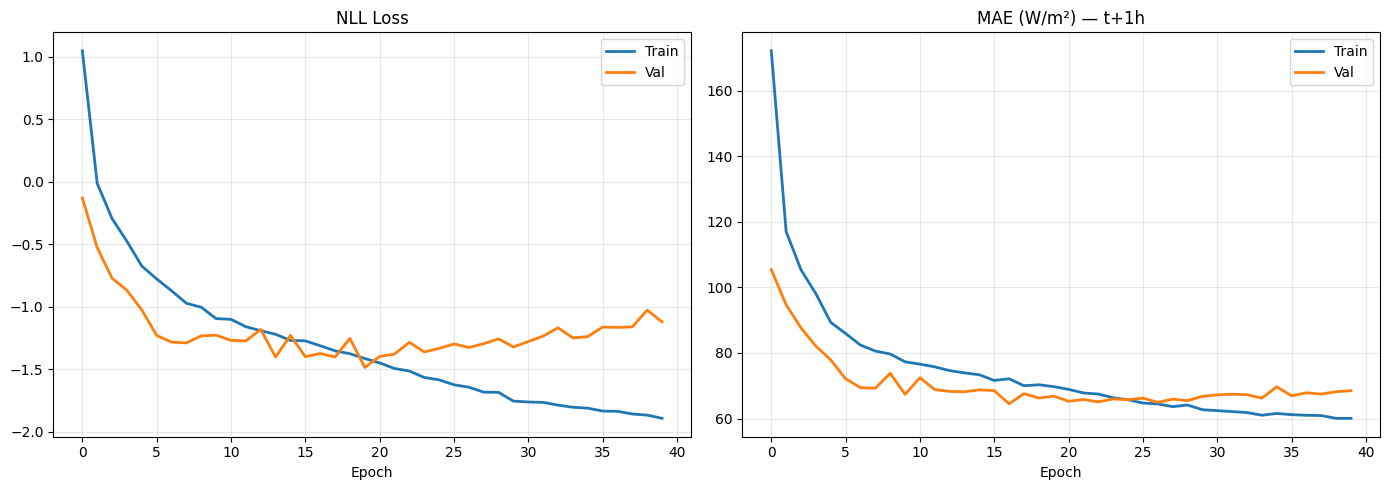

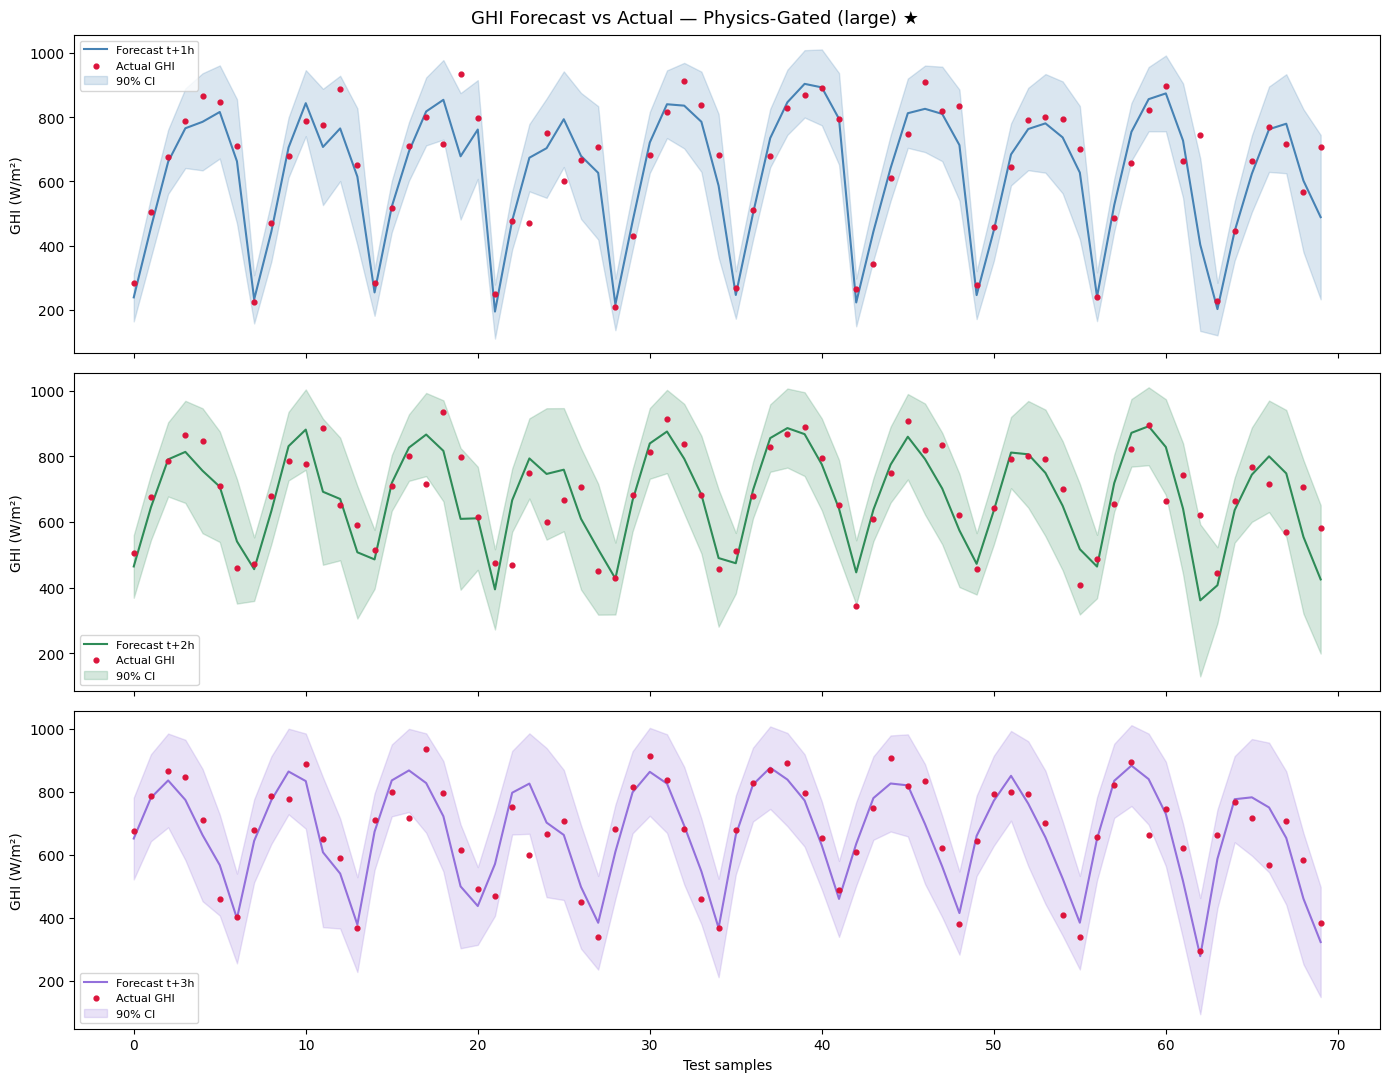

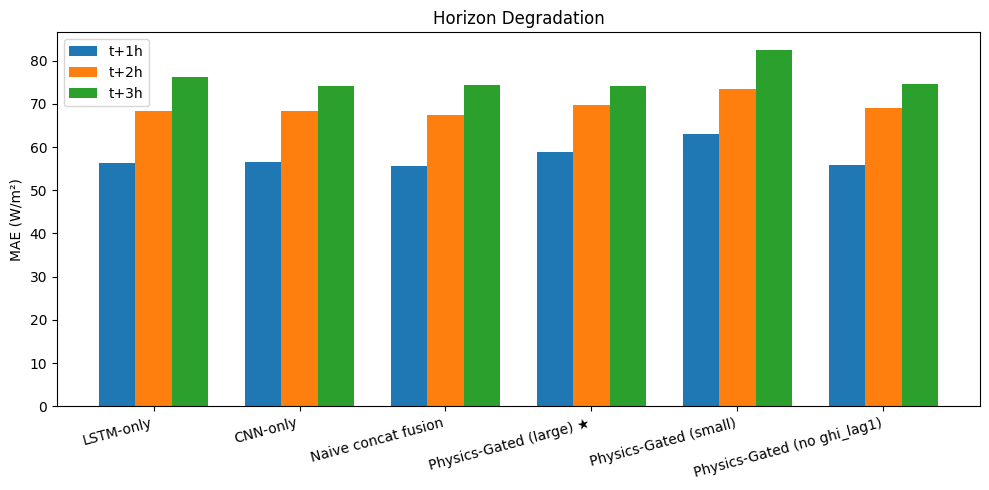

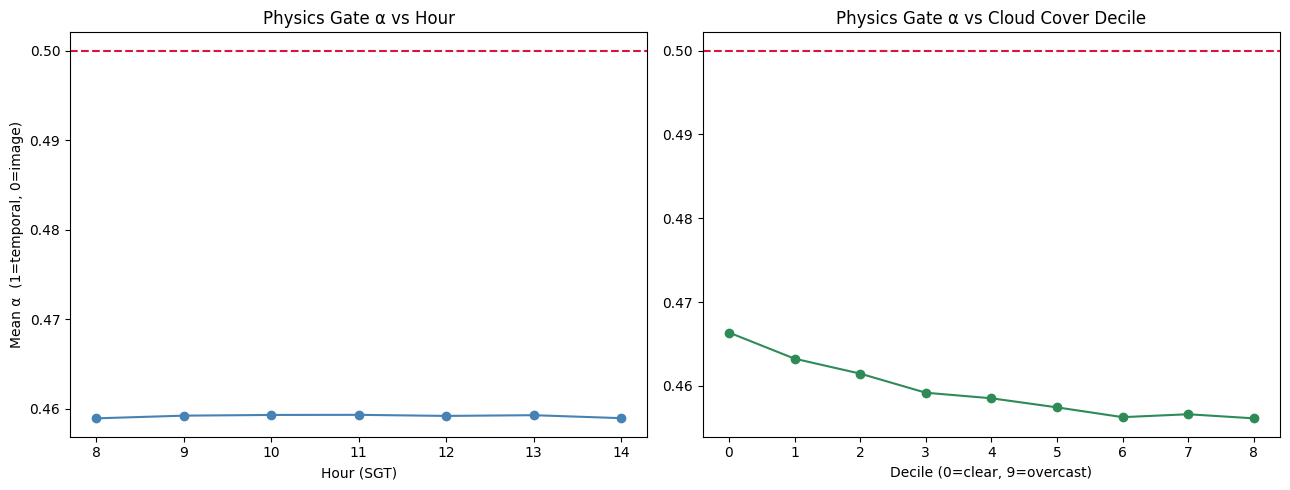

In [17]:
# Pick which experiment to plot (must exist in pred_cache)
_PLOT_KEY = next((k for k in ["Physics-Gated (large) ★", "LSTM-only"]
                  if k in pred_cache), list(pred_cache)[0])
print(f"Plotting: {_PLOT_KEY}")

# 9a. Training curves
if history and len(history["train_nll"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_nll"], label="Train", lw=2)
    axes[0].plot(history["val_nll"],   label="Val",   lw=2)
    axes[0].set_title("NLL Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_mae"], label="Train", lw=2)
    axes[1].plot(history["val_mae"],   label="Val",   lw=2)
    axes[1].set_title("MAE (W/m²) — t+1h"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULTS}/plots/training_curves.png", dpi=150)
    plt.show()

# 9b. Forecast vs Actual
N = 70
mu_p, sig_p, tar_p = [x[:N] for x in pred_cache[_PLOT_KEY]]
n  = len(tar_p)                     # actual points available, may be < N
xs = np.arange(n)

fig, axs = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for h, col in enumerate(["steelblue", "seagreen", "mediumpurple"]):
    lo = mu_p[:n, h] - 1.645*sig_p[:n, h]
    hi = mu_p[:n, h] + 1.645*sig_p[:n, h]
    axs[h].plot(xs, mu_p[:n, h], color=col, lw=1.5, label=f"Forecast t+{h+1}h")
    axs[h].scatter(xs, tar_p[:n, h], color="crimson", s=12, zorder=5,
                   label="Actual GHI")
    axs[h].fill_between(xs, lo, hi, alpha=0.2, color=col, label="90% CI")
    axs[h].set_ylabel("GHI (W/m²)"); axs[h].legend(fontsize=8)
axs[2].set_xlabel("Test samples")
plt.suptitle(f"GHI Forecast vs Actual — {_PLOT_KEY}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/forecast_vs_actual.png", dpi=150); plt.show()

# 9c. Horizon degradation
deep = list(eval_horizons.keys())
h1 = [eval_horizons[n][0]["MAE_Wm2"] for n in deep]
h2 = [eval_horizons[n][1]["MAE_Wm2"] for n in deep]
h3 = [eval_horizons[n][2]["MAE_Wm2"] for n in deep]
x, w = np.arange(len(deep)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, h1, w, label="t+1h"); ax.bar(x, h2, w, label="t+2h"); ax.bar(x+w, h3, w, label="t+3h")
ax.set_xticks(x); ax.set_xticklabels(deep, rotation=15, ha="right")
ax.set_ylabel("MAE (W/m²)"); ax.set_title("Horizon Degradation"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/horizon_degradation.png", dpi=150); plt.show()

# 9d. Physics gate analysis
model_full.eval()
all_alpha, all_hours, all_cloud = [], [], []
with torch.no_grad():
    for batch in test_loader:
        tab = batch["tabular_seq"].to(device)
        mf  = batch["multi_frame"].to(device)
        roi = batch["roi_image"].to(device)
        fc  = batch["future_clearsky"].to(device)
        gf  = batch["gate_features"].to(device)
        _, _, alpha, _ = model_full(tab, mf, roi, fc, gf, return_attn=True)
        all_alpha.append(alpha.cpu().view(-1))
        all_cloud.append(batch["gate_features"][:,1]*100)
        all_hours.append(test_dataset.df.iloc[
            [test_dataset.valid_indices[i] for i in range(len(batch["idx"]))]]["hour"].values)

all_alpha = torch.cat(all_alpha).numpy()
all_cloud = torch.cat(all_cloud).numpy()
all_hours = np.concatenate(all_hours)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
gdf = pd.DataFrame({"alpha": all_alpha, "hour": all_hours})
hm  = gdf.groupby("hour")["alpha"].mean()
axs[0].plot(hm.index, hm.values, marker="o", color="steelblue")
axs[0].axhline(0.5, color="crimson", linestyle="--")
axs[0].set_title("Physics Gate α vs Hour"); axs[0].set_xlabel("Hour (SGT)")
axs[0].set_ylabel("Mean α  (1=temporal, 0=image)")
cdf = pd.DataFrame({"alpha": all_alpha, "cloud": all_cloud})
cdf["dec"] = pd.qcut(cdf["cloud"], 10, duplicates="drop", labels=False)
cm  = cdf.groupby("dec")["alpha"].mean()
axs[1].plot(cm.index, cm.values, marker="o", color="seagreen")
axs[1].axhline(0.5, color="crimson", linestyle="--")
axs[1].set_title("Physics Gate α vs Cloud Cover Decile")
axs[1].set_xlabel("Decile (0=clear, 9=overcast)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/plots/gate_analysis.png", dpi=150); plt.show()


In [18]:
# ── Save training statistics (required by predict.py / verify.py) ─────────────
import json
stats = {k: v.tolist() if hasattr(v, "tolist") else v for k, v in train_stats.items()}
with open(f"{ROOT}/train_stats.json", "w") as f:
    json.dump(stats, f)
print(f"Saved {ROOT}/train_stats.json ✓")

# ── What to copy back to your project folder after training ───────────────────
print("""
════════════════════════════════════════════════════════════════
  TRAINING COMPLETE — copy these back to your Project folder:
    • best_model.pt          (the model predict.py loads)
    • train_stats.json       (normalisation stats — REQUIRED)
    • results/               (metrics + plots)
    • best_model_lstm/cnn/concat.pt   (optional, ablations)
    • swimseg_encoder.pt     (optional, reusable for future runs)

  Then on your Mac:  python predict.py   →   python verify.py
════════════════════════════════════════════════════════════════
""")

Saved /Users/qasimnalawala/Desktop/Project/train_stats.json ✓

════════════════════════════════════════════════════════════════
  TRAINING COMPLETE — copy these back to your Project folder:
    • best_model.pt          (the model predict.py loads)
    • train_stats.json       (normalisation stats — REQUIRED)
    • results/               (metrics + plots)
    • best_model_lstm/cnn/concat.pt   (optional, ablations)
    • swimseg_encoder.pt     (optional, reusable for future runs)

  Then on your Mac:  python predict.py   →   python verify.py
════════════════════════════════════════════════════════════════

